# EJERCICIO 2

PUNTO 1

In [42]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

alimentos = pd.read_csv("datasets/alimentos.csv", encoding='latin-1', delimiter=';')
pacientes = pd.read_csv("datasets/pacientes.csv", encoding='latin-1', delimiter=';')

#alimentos.info()
#alimentos.columns
#alimentos.head(15)

#pacientes.info() 
#pacientes.columns
#pacientes.head(15)

# Veo que la altura se encuentra en str, lo paso a float
pacientes['altura_m'] = pacientes['altura_m'].str.replace(',', '.')
pacientes['altura_m'] = pacientes['altura_m'].astype(float)

alimentos.info()
pacientes.info()


<class 'pandas.DataFrame'>
RangeIndex: 99 entries, 0 to 98
Data columns (total 4 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   alimento              99 non-null     str  
 1   aporte_calorico_kcal  99 non-null     int64
 2   tipo_de_alimento      99 non-null     str  
 3   vitamina              99 non-null     str  
dtypes: int64(1), str(3)
memory usage: 4.9 KB
<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 6 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   codigo_paciente          50 non-null     int64  
 1   peso_inicial_kg          50 non-null     int64  
 2   peso_final_kg            50 non-null     int64  
 3   altura_m                 50 non-null     float64
 4   sexo                     50 non-null     str    
 5   tiempo_tratamiento_dias  50 non-null     int64  
dtypes: float64(1), int64(4), str(1)
memory us

PUNTO 2

In [ ]:
# kcal que aportan en promedio los alimentos del dataset
alimentos['aporte_calorico_kcal'].mean()

# valor calorico que tal que el 50% de los valores del dataset son menores o igual que el (mediana)
alimentos['aporte_calorico_kcal'].median()

# valores que se presentan con mayor frecuencia
alimentos['aporte_calorico_kcal'].mode()

# variabilidad en el 50% central de los datos
riq = alimentos['aporte_calorico_kcal'].quantile(0.75) - alimentos['aporte_calorico_kcal'].quantile(0.25)
#print(riq)

62.0


PUNTO 3

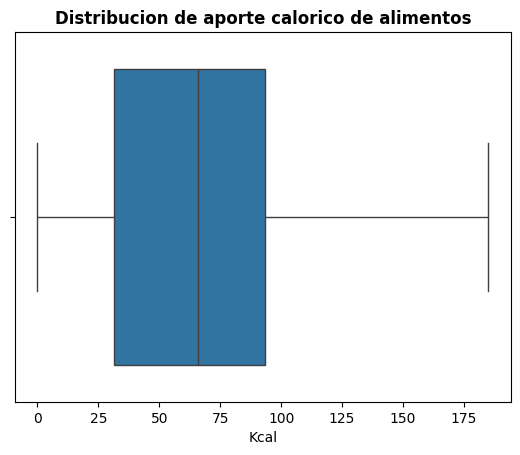

99


In [ ]:
# Creo el boxplot con seaborn. Uso showfliers=False para ocultar los outliers y que asi se vea mejor el boxplot
sns.boxplot(x='aporte_calorico_kcal', data=alimentos, showfliers=False)

# Lo emprolijo con matplotlib
plt.title("Distribucion de aporte calorico de alimentos", fontweight="bold")
plt.xlabel("Kcal")
plt.show()

# Existen bastantes posiciones atipicas. Estas son las que son menores que el RIQ * 1.5 y mayores que el RIQ * 1.5.
limite_inf = alimentos['aporte_calorico_kcal'].quantile(0.75) + (riq * 1.5)
limite_sup = alimentos['aporte_calorico_kcal'].quantile(0.25) - (riq * 1.5)
outliers = alimentos[(alimentos['aporte_calorico_kcal'] < limite_inf) | (alimentos['aporte_calorico_kcal'] > limite_sup)]
cant_outliers = len(outliers)
print(cant_outliers)

# Se nota una clara asimetria hacia la derecha de de la distribucion
# Para describir este conjunto de datos las medidas mas adecuadas me parecen: la mediana y el RIQ, ya que estas no se ven 
# tan afectadas por los outliers